In [ ]:
# install a specialized Python package - "diff-gaussian-rasterization" into the active venv
# !pip install git+https://github.com/graphdeco-inria/diff-gaussian-rasterization.git --no-build-isolation

In [1]:
import warnings
import torch

# Suppress all warnings
warnings.filterwarnings("ignore")

In [ ]:
# Multi-view diffusion
import torch
from diffusers import DiffusionPipeline

multi_view_diffusion_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/multi-view-diffusion",
    custom_pipeline="dylanebert/multi-view-diffusion",
    torch_dtype=torch.float16,
    trust_remote_code=True,
).to("cuda")

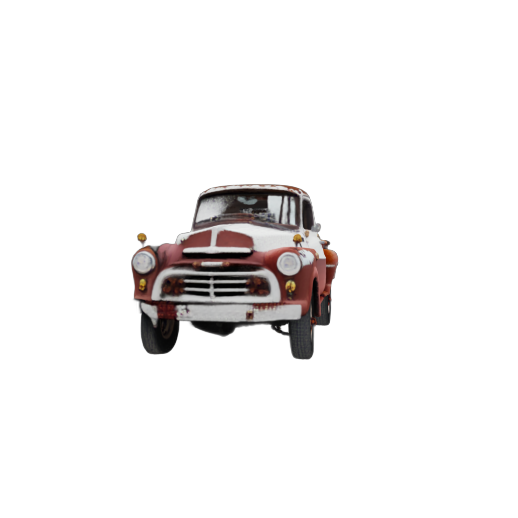

In [3]:
from PIL import Image
import numpy as np
from rembg import remove

image_path = "../img/image.png" 
image = Image.open(image_path)

# Remove the background (this outputs an RGBA image with transparency)
image_rgba = remove(image)

# For Gaussian Splatting / Diffusion, a clean white background is often preferred over transparency
white_bg = Image.new("RGBA", image_rgba.size, "WHITE")
white_bg.paste(image_rgba, (0, 0), image_rgba)

# Convert to RGB
image = white_bg.convert("RGB")

image

100%|██████████| 30/30 [00:04<00:00,  6.74it/s]


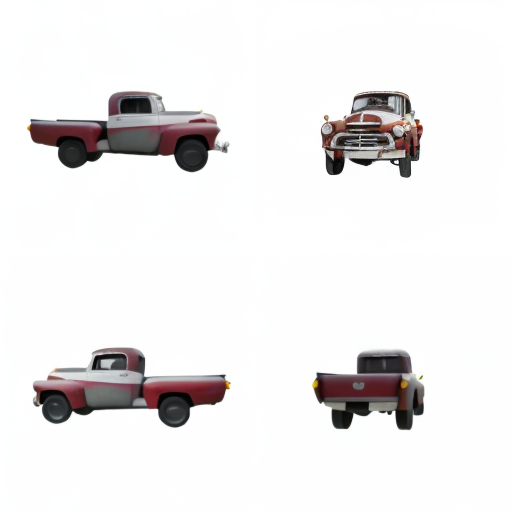

In [4]:
import numpy as np

def create_image_grid(images):
    images = [Image.fromarray((img * 255).astype("uint8")) for img in images]

    width, height = images[0].size
    grid_img = Image.new("RGB", (2 * width, 2 * height))

    grid_img.paste(images[0], (0, 0))
    grid_img.paste(images[1], (width, 0))
    grid_img.paste(images[2], (0, height))
    grid_img.paste(images[3], (width, height))

    return grid_img

# prepare the image by converting it to a normalized numpy array
image = np.array(image, dtype=np.float32) / 255.0
images = multi_view_diffusion_pipeline(
    "",                         # text prompt input
    image,                      # source 2D image
    guidance_scale=5,           # Classifier-Free Guidance (CFG) -> control how much creative freedom the model has
    num_inference_steps=30,     # the number of denoising steps
    elevation=0                 # specify the camera's vertical angle (in degrees) relative to the object for the generated views
)

create_image_grid(images)

In [5]:
# Load the generative Gaussian Splatting model
splat_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/LGM",
    custom_pipeline="dylanebert/LGM",
    torch_dtype=torch.float16,
    trust_remote_code=True,
).to("cuda")

Loading pipeline components...: 100%|██████████| 1/1 [00:00<00:00,  2.40it/s]


In [6]:
# Run the pipeline to generate the splat data
splat = splat_pipeline(images)

output_path = "output.ply"
splat_pipeline.save_ply(splat, output_path)
print(f"File successfully saved locally to: {output_path}")

File successfully saved locally to: output.ply


In [ ]:
import gradio as gr

def run(image):
    input_image = image.astype("float32") / 255.0
    images = multi_view_diffusion_pipeline("", input_image, guidance_scale=5, num_inference_steps=30, elevation=0)
    splat = splat_pipeline(images)
    output_path = "output.ply"
    splat_pipeline.save_ply(splat, output_path)
    return output_path

demo = gr.Interface(fn=run, inputs="image", outputs=gr.Model3D())
demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


100%|██████████| 30/30 [00:04<00:00,  6.52it/s]
